# Laboratorium 1

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [22]:
observations=1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [23]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


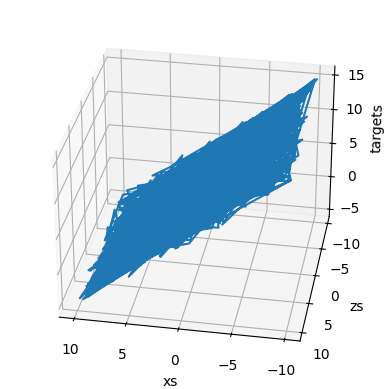

In [ ]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()

In [ ]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[0.07509658]
 [0.02423417]] [-0.08528578]


In [ ]:
targets = targets.reshape(observations, 1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

31.319143439300028
14.580621749437043
12.256804922006422
11.578912271149475
11.104582495037171
10.669263731285255
10.253505662913472
9.854470229178006
9.471255972608724
9.103208795163093
8.74972524042573
8.410228649428033
8.084165527906555
7.771004324263666
7.470234524765537
7.181365816690144
6.903927288462217
6.6374666619081335
6.381549554947027
6.135758773463393
5.899693631200283
5.672969296563624
5.45521616527267
5.246079257833939
5.045217640856338
4.852303871264161
4.667023462501873
4.489074371860536
4.3181665080900835
4.1540212584947795
3.9963710347409296
3.8449588366364136
3.6995378331709428
3.5598709601340217
3.4257305336546833
3.2968978790329837
3.173162974258166
3.054324107632387
2.9401875489418448
2.8305672336392607
2.7252844595228747
2.624167595417481
2.527051801382591
2.4337787599916254
2.344196418244047
2.258158739689726
2.1755254663614254
2.0961618901273424
2.0199386330909284
1.9467314366800388
1.8764209590815502
1.808892580691251
1.7440362172618336
1.6817461404443972
1.6

In [ ]:
print(weights, biases)

[[-9.96779598e-01]
 [ 4.66615529e-06]] [4.30689115]


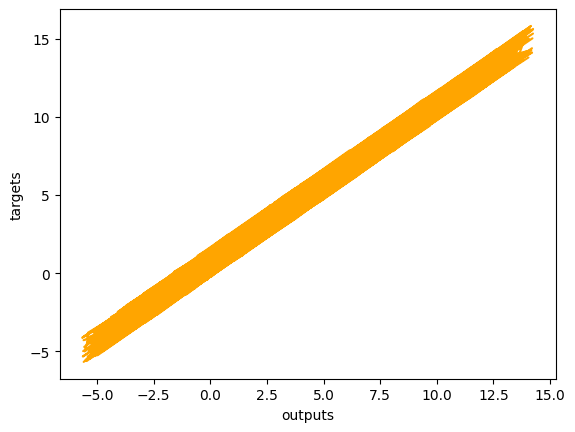

In [ ]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

# Ćwiczenie

## Zmiana ilości próbek na 1000000

Przy zwiększeniu ilości danych bez zmiany wariancji, co logiczne, dostajemy lepszy wynik. Wagi x i z są dużo bliżej do rzeczwistych, jak i bias

In [ ]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 0.02

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[-0.00463168]
 [-0.01213672]] [0.04033625]

Straty
--------------------------------------------------
28.987938508740516
13.815529572998052
11.717225581578038
11.086867266701828
10.635225345052223
10.218539118619729
9.820248952210976
9.437941501723701
9.070796788497166
8.718193599285902
8.379553783872458
8.054324136659824
7.741973586581376
7.441992118252401
7.153889915702161
6.877196559983201
6.611460260772313
6.356247118646289
6.111140416598935
5.875739939616969
5.649661321201102
5.432535415764869
5.224007695886555
5.0237376734298245
4.831398343588104
4.646675650944691
4.469267976676975
4.29888564606729
4.135250455516401
3.9780952182872213
3.827163328237083
3.6822083408262207
3.5429935707183056
3.4092917053160035
3.2808844336005176
3.157562089669104
3.0391233103884807
2.9253747066051616
2.8161305473758755
2.7112124567024534
2.61044912227601
2.513676015754853
2.420735124119397
2.3314746916654174
2.2457489722143698
2.1634179911361757
2.084347316795924
2.00

In [ ]:
observations=1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 0.0001

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[0.00492482]
 [0.05889169]] [-0.02026232]

Straty
--------------------------------------------------
31.683168673652876
31.549188066603413
31.416118760831246
31.28395444294714
31.152688843347562
31.0223157359108
30.892828937695295
30.764222308639976
30.636489751266737
30.509625210384947
30.383622672798033
30.258476167012063
30.134179762946413
30.010727571646388
29.88811374499785
29.766332475443843
29.645377995703186
29.525244578490987
29.405926536241147
29.287418220830737
29.169714023306334
29.05280837361223
28.936695740320538
28.82137063036317
28.706827588765663
28.593061198382877
28.48006607963652
28.36783689025446
28.25636832501192
28.1456551154744
28.03569202974239
27.926473872197935
27.817995483252822
27.710251739098677
27.603237551458623
27.49694786734083
27.39137766879364
27.28652197266248
27.182375830348427
27.078934327568422
26.976192584117236
26.874145753630966
26.772789023352292
26.67211761389729
26.572126779023872
26.47281180540185
26.37416801

In [ ]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 0.001

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[0.01320389]
 [0.08753945]] [0.08403226]

Straty
--------------------------------------------------
29.455957864351074
28.304386933338677
27.226748438982288
26.218200332404944
25.274217879724674
24.39057286696929
23.563314167789226
22.788749584658213
22.063428880104237
21.3841279199824
20.747833855911946
20.151731278776932
19.593189279651412
19.069749358681825
18.57911412635586
18.119136745228854
17.68781106358239
17.28326239566919
16.903738906170865
16.547603559271224
16.213326595343755
15.89947850067573
15.604723437918487
15.327813107069922
15.067581008774695
14.822937083576381
14.592862702483561
14.376405985826795
14.172677428891978
13.980845814225612
13.800134391825148
13.629817309658526
13.469216278107789
13.317697453006694
13.174668522946735
13.039575987465046
12.91190261360474
12.79116505915821
12.676911651669851
12.568720312990608
12.466196619845583
12.368971991501326
12.276701996203263
12.189064768599732
12.105759530879176
12.026505210823808
11.9

In [ ]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 0.1

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[-0.08839936]
 [-0.02327261]] [-0.05430685]

Straty
--------------------------------------------------
26.777553119852143
85.84602338906132
418.68335919820544
2239.877364579151
12162.478052958999
66190.5963266296
360343.64723584976
1961821.284656927
10680839.516870648
58150294.8684042
316591038.42674637
1723635437.295761
9384092988.174538
51090397307.83852
278154663740.70154
1514375239667.569
8244811714018.769
44887774239320.04
244385529886948.88
1330524850740318.8
7243868859210796.0
3.943830615471702e+16
2.1471679405896755e+17
1.1689982447266775e+18
6.364463330685521e+18
3.4650523661067133e+19
1.8865047361277277e+20
1.0270842766125508e+21
5.591834956497883e+21
3.04440685560713e+22
1.6574907753695402e+23
9.02401130541865e+23
4.913016502448051e+24
2.674834377383555e+25
1.456282565510126e+26
7.928563057925765e+26
4.316615829324827e+27
2.350132741349641e+28
1.2795034648212288e+29
6.966114658447481e+29
3.792624525308963e+30
2.0648530901438075e+31
1.1241869632

In [ ]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*xs + 5+ noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 1

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[-0.06046575]
 [-0.0476643 ]] [-0.09246549]

Straty
--------------------------------------------------
27.84221609211436
15403.53974494067
16129613.046347834
16890310018.546213
17687109331106.688
1.8521734455231176e+16
1.939599178120085e+19
2.0311774446342482e+22
2.127106652217757e+25
2.2275947404811045e+28
2.332859641829909e+31
2.443129764135797e+34
2.5586444968306587e+37
2.679654741565239e+40
2.806423468629394e+43
2.939226300390624e+46
3.0783521230669056e+49
3.224103728216447e+52
3.376798485394692e+55
3.5367690474970274e+58
3.7043640903843835e+61
3.8799490884625633e+64
4.063907127971232e+67
4.2566397598243204e+70
4.458567893931745e+73
4.670132737027685e+76
4.8917967761322187e+79
5.1240448098748615e+82
5.367385030016805e+85
5.6223501556277246e+88
5.8894986224884016e+91
6.169415830419864e+94
6.46271545137008e+97
6.7700408012324435e+100
7.092066278506472e+103
7.42949887307732e+106
7.783079748539704e+109
8.153585901668234e+112
8.541831902804851e+115
8.94867

In [ ]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs - 7*xs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Wagi i bias przed skalowaniem")
print(weights, biases)
print("="*50)
print()

targets = targets.reshape(observations, 1)
eta = 0.02

print("Straty")
print("-"*50)
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

print("="*50)
print("Wagi i bias po skalowaniu")
print(weights, biases)

Wagi i bias przed skalowaniem
[[0.09529869]
 [0.01880831]] [-0.06994491]

Straty
--------------------------------------------------
652.3146618569842
133.22610708700913
73.02050856972978
64.01704527826881
60.80714722838211
58.32990153555555
56.01819571297328
53.80554439398017
51.68135041729743
49.64136750530018
47.68217811497751
45.80057360907249
43.993480605979464
42.257948342318784
40.59114300632029
38.99034301623226
37.452934565963304
35.97640735605528
34.55835049470523
33.19644856121655
31.888477825350268
30.63230261639075
29.425871835996112
28.26721560913966
27.154442067673777
26.085734261264204
25.059347190651277
24.073604958393553
23.126898032442
22.217680618076088
21.34446813391119
20.50583478785592
19.700411249061155
18.9268824120598
18.183985249446412
17.470506749590466
16.785281936016144
16.12719196521424
15.495162299780793
14.88816095389929
14.305196808301321
13.745317991954996
13.207610327838141
12.691195840258809
12.195231321285796
11.718906953948323
11.26144498995691
10.